# Lab 3 — Semantic Search

Run this notebook top to bottom as you build out `embeddings.py` and `search.py` in this same folder. See `Lab3_Instructions.md` for what belongs in each step.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the corpus, example queries, and visualization are yours to write.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from search import load_documents, build_embedding_matrix, search

EMBEDDING_MODE=api
API_KEY=found


## Step 1-2: Load your corpus and fetch embeddings

In [2]:
# TODO: load_documents("documents.json") and build_embedding_matrix(documents)
# Start in offline mode (the default) while you're building - switch to the real
# API once your pipeline works end to end.

documents = load_documents("documents.json")

embedding_matrix = build_embedding_matrix(documents)

print(embedding_matrix.shape)





# import os
# from pathlib import Path

# from dotenv import load_dotenv

# load_dotenv()

# API_KEY = os.environ.get("NVIDIA_API_KEY")

# if not API_KEY:
#     print("\nERROR: NVIDIA_API_KEY was not found.")
#     print("Create a .env file containing:")
#     print('NVIDIA_API_KEY="nvapi-your-key-here"')
#     print("or export the variable in your terminal.")
#     raise SystemExit(1)

# URL = "https://integrate.api.nvidia.com/v1/chat/completions"
# print(Path.cwd())

# BASE_DIR = Path(__file__).resolve().parent

# CONVERSATION_DIR = Path("conversations")
# CONVERSATION_FILE = CONVERSATION_DIR / "chat1.json"



# endpoint = "https://integrate.api.nvidia.com/v1/embeddings"
# Auth_header = f"Authorization: Bearer {API_KEY}"
# model = "nvidia/nv-embedqa-e5-v5"



Generating embeddings...
using API
using API
using API
using API
using API
using API
using API
using API
using API
using API
using API
using API
using API
using API
using API
using API
using API
using API
using API
using API
(20, 1024)


## Step 3: Run a few example search queries

In [3]:
# TODO: call search(query, embedding_matrix, documents, top_k=3) with at least two
# different queries and print the results

queries = [
    "quantum mechanics",
    "deep learning"
]

for query in queries:

    print("=" * 60)
    print("Query:", query)

    results = search(
        query,
        embedding_matrix,
        documents,
        top_k=3
    )

    for result in results:

        print(f"Score: {result['score']:.4f}")
        print("Topic:", result["document"]["topic"])
        print(result["document"]["text"])
        print()


Query: quantum mechanics
using API
Score: 0.4616
Topic: Physics
Quantum mechanics is the branch of physics that describes the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. Unlike classical physics, quantum mechanics uses wavefunctions to represent the probabilistic state of a particle, meaning we can only predict the likelihood of finding a particle in a particular position or state. Key principles include wave-particle duality, where particles exhibit both wave-like and particle-like properties, and Heisenberg's uncertainty principle, which states that we cannot simultaneously know both the exact position and momentum of a particle with perfect accuracy.

Score: 0.2932
Topic: Physics
The speed of light in a vacuum, approximately 299,792,458 meters per second, is considered the ultimate speed limit in the universe according to Einstein's theory of special relativity. This constant, denoted as 'c', plays a fundamental role in the relationsh

## Step 4: Visualize the embedding space with PCA

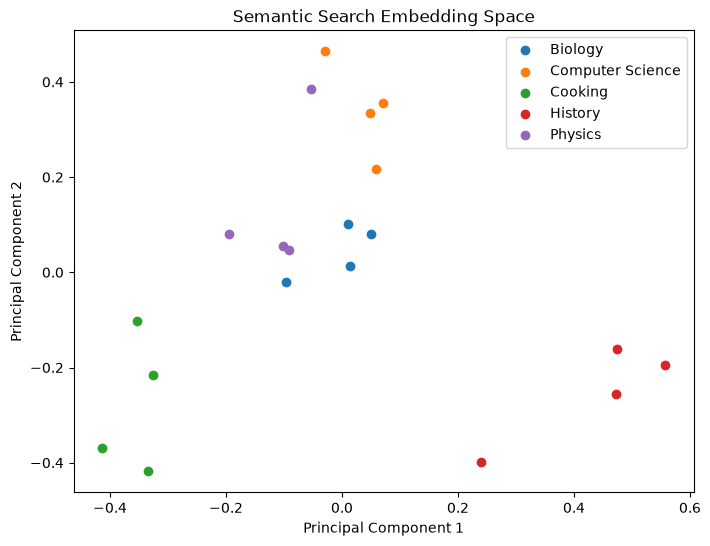

In [4]:
# TODO: reuse your Lab 2 PCA-via-SVD function (extended to 2 components) to project
# the embedding matrix down to 2D, then scatter-plot it colored by topic

import numpy as np

def pca_via_svd(data, n_components):

    mean = data.mean(axis=0)

    centered_data = data - mean

    U, S, Vt = np.linalg.svd(
        centered_data,
        full_matrices=False
    )

    components = Vt[:n_components]

    projection = centered_data @ components.T

    return projection, components

projection, components = pca_via_svd(
    embedding_matrix,
    n_components=2
)



topics = [doc["topic"] for doc in documents]

unique_topics = sorted(set(topics))

plt.figure(figsize=(8,6))

for topic in unique_topics:

    idx = [
        i
        for i, doc in enumerate(documents)
        if doc["topic"] == topic
    ]

    plt.scatter(
        projection[idx, 0],
        projection[idx, 1],
        label=topic
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Semantic Search Embedding Space")

plt.legend()

plt.show()
